Sample-specific persistent activity
-----------------------------------

Five subpopulations with three selective and one reset stimuli example.
Analog to figure 6b in the paper.

BRUNEL, Nicolas et WANG, Xiao-Jing. Effects of neuromodulation in a cortical network model of object working memory 
dominated by recurrent inhibition. Journal of computational neuroscience, 2001, vol. 11, no 1, p. 63-85.

copy from https://github.com/brian-team/brian2/blob/master/examples/frompapers/Brunel_Wang_2001.py


In [1]:
import yaml
import brian2
from brian2 import Hz, ms
import numpy
import load_models
import matplotlib.pyplot as plt

In [2]:
brian2.prefs.devices.cpp_standalone.openmp_threads = 3

In [3]:
with open('neuron_model.txt', 'r') as model_f, open('neuron_parameters.yaml', 'r') as params_f:
    neurongroup_dict = load_models.load_neurongroups(
        model_f.read(),
        yaml.safe_load(params_f)
    )
#neurongroup_dict['Pyramidal_Cells'].v = -70 * brian2.mV
#neurongroup_dict['Interneurons'].v = -70 * brian2.mV
print(neurongroup_dict)

{'Pyramidal_Cells': NeuronGroup(clock=Clock(dt=100. * usecond, name='defaultclock'), when=start, order=0, name='Pyramidal_Cells'), 'Interneurons': NeuronGroup(clock=Clock(dt=100. * usecond, name='defaultclock'), when=start, order=0, name='Interneurons')}


In [4]:
import json

class QuantityJSONEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, brian2.Quantity):
            return str(obj)
        return super().default(obj)

print(json.dumps(neurongroup_dict['Pyramidal_Cells'].namespace, cls=QuantityJSONEncoder, indent=2))
print(json.dumps(neurongroup_dict['Interneurons'].namespace, cls=QuantityJSONEncoder, indent=2))

{
  "V_L": "-70. mV",
  "V_E": "0. V",
  "V_I": "-70. mV",
  "C_m": "0.5 nF",
  "g_m": "25. nS",
  "g_AMPA_ext": "2.08 nS",
  "g_AMPA_rec": "104. pS",
  "tau_AMPA": "2. ms",
  "g_NMDA_rec": "0.327 nS",
  "Mg2": 1,
  "g_GABA_rec": "1.25 nS",
  "tau_GABA": "10. ms"
}
{
  "V_L": "-70. mV",
  "V_E": "0. V",
  "V_I": "-70. mV",
  "C_m": "200. pF",
  "g_m": "20. nS",
  "g_AMPA_ext": "1.62 nS",
  "g_AMPA_rec": "81. pS",
  "tau_AMPA": "2. ms",
  "g_NMDA_rec": "258. pS",
  "Mg2": 1,
  "g_GABA_rec": "0.973 nS",
  "tau_GABA": "10. ms"
}


In [5]:
# external stimuli
rate = 3 * Hz
C_ext = 800

# subpopulations
f = 0.1
p = 5
N_sub = int(neurongroup_dict['Pyramidal_Cells']._N * f)
N_non = int(neurongroup_dict['Pyramidal_Cells']._N * (1. - f * p))
w_plus = 2.1
w_minus = 1. - f * (w_plus - 1.) / (1. - f)
print(N_non, w_minus)

400 0.8777777777777778


In [6]:
with open('synapse_models.yaml', 'r') as models_f, open('synapse_parameters.yaml', 'r') as params_f:
    synapse_dict = load_models.load_synapses(
        neurongroup_dict,
        yaml.safe_load(models_f),
        yaml.safe_load(params_f)
    )
C_E_E = synapse_dict['AMPA_NMDA_rec']['Pyramidal_Cells']['Pyramidal_Cells']
C_E_E.w[C_E_E.indices[:, :]] = w_minus
C_E_E.w[C_E_E.indices[:, :N_non]] = 1.
for pi in range(N_non, N_non + p*N_sub, N_sub):
    C_E_E.w[C_E_E.indices[pi:pi+N_sub, pi:pi+N_sub]] = w_plus

C_E_I = synapse_dict['AMPA_NMDA_rec']['Pyramidal_Cells']['Interneurons']
C_E_I.w[:] = 1.

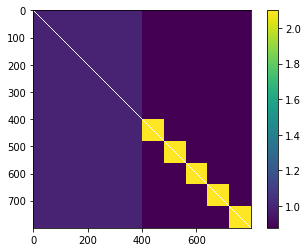

1.0


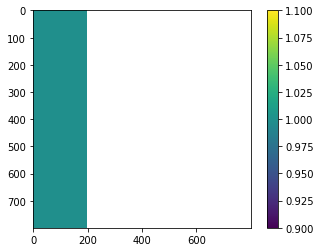

1.0


In [7]:
for C in [C_E_E, C_E_I]:
    W = numpy.full((neurongroup_dict['Pyramidal_Cells']._N, neurongroup_dict['Pyramidal_Cells']._N), numpy.nan)
    W[C.i[:], C.j[:]] = C.w[:]
    plt.imshow(W)
    plt.colorbar()
    plt.show()
    print(W[0, 1])

In [8]:
print(json.dumps(C_E_E.namespace, cls=QuantityJSONEncoder, indent=2))
print(json.dumps(C_E_I.namespace, cls=QuantityJSONEncoder, indent=2))

{
  "tau_NMDA_rise": "2. ms",
  "tau_NMDA_decay": "100. ms",
  "alpha": "0.5 kHz"
}
{
  "tau_NMDA_rise": "2. ms",
  "tau_NMDA_decay": "100. ms",
  "alpha": "0.5 kHz"
}


In [9]:
# external noise
C_P_E = brian2.PoissonInput(neurongroup_dict['Pyramidal_Cells'], 's_AMPA_ext', C_ext, rate, '1')
C_P_I = brian2.PoissonInput(neurongroup_dict['Interneurons'], 's_AMPA_ext', C_ext, rate, '1')

In [10]:
# at 1s, select population 1
C_selection = int(f * C_ext)
rate_selection = 25 * Hz
stimuli1 = brian2.TimedArray(numpy.r_[numpy.zeros(40), numpy.ones(2), numpy.zeros(100)], dt=25 * ms)
input1 = brian2.PoissonInput(neurongroup_dict['Pyramidal_Cells'][N_non:N_non + N_sub], 's_AMPA_ext', C_selection, rate_selection, 'stimuli1(t)')

# at 2s, select population 2
stimuli2 = brian2.TimedArray(numpy.r_[numpy.zeros(80), numpy.ones(2), numpy.zeros(100)], dt=25 * ms)
input2 = brian2.PoissonInput(neurongroup_dict['Pyramidal_Cells'][N_non + N_sub:N_non + 2 * N_sub], 's_AMPA_ext', C_selection, rate_selection, 'stimuli2(t)')

# at 3s, reset selection
stimuli_reset = brian2.TimedArray(numpy.r_[numpy.zeros(120), numpy.ones(2), numpy.zeros(100)], dt=25 * ms)
input_reset_I = brian2.PoissonInput(neurongroup_dict['Pyramidal_Cells'], 's_AMPA_ext', C_ext, rate_selection, 'stimuli_reset(t)')
input_reset_E = brian2.PoissonInput(neurongroup_dict['Interneurons'], 's_AMPA_ext', C_ext, rate_selection, 'stimuli_reset(t)')

In [11]:
# monitors
N_activity_plot = 15
sp_E_sels = [brian2.SpikeMonitor(neurongroup_dict['Pyramidal_Cells'][pi:pi + N_activity_plot]) for pi in range(N_non, N_non + p * N_sub, N_sub)]
sp_E = brian2.SpikeMonitor(neurongroup_dict['Pyramidal_Cells'][:N_activity_plot])
sp_I = brian2.SpikeMonitor(neurongroup_dict['Interneurons'][:N_activity_plot])

r_E_sels = [brian2.PopulationRateMonitor(neurongroup_dict['Pyramidal_Cells'][pi:pi + N_sub]) for pi in range(N_non, N_non + p * N_sub, N_sub)]
r_E = brian2.PopulationRateMonitor(neurongroup_dict['Pyramidal_Cells'][:N_non])
r_I = brian2.PopulationRateMonitor(neurongroup_dict['Interneurons'])

In [12]:
print(list(synapse_dict['AMPA_NMDA_rec']['Pyramidal_Cells'].values()))
print(list(synapse_dict['AMPA_NMDA_rec']['Interneurons'].values()))
print(list(synapse_dict['GABA_rec']['Pyramidal_Cells'].values()))
print(list(synapse_dict['GABA_rec']['Interneurons'].values()))

[Synapses(clock=Clock(dt=100. * usecond, name='defaultclock'), when=start, order=0, name='AMPA_NMDA_rec_fromPCtoPC'), Synapses(clock=Clock(dt=100. * usecond, name='defaultclock'), when=start, order=0, name='AMPA_NMDA_rec_fromPCtoI')]
[]
[]
[Synapses(clock=Clock(dt=100. * usecond, name='defaultclock'), when=start, order=0, name='GABA_rec_fromItoPC'), Synapses(clock=Clock(dt=100. * usecond, name='defaultclock'), when=start, order=0, name='GABA_rec_fromItoI')]


In [18]:
net = brian2.Network()
net.add(neurongroup_dict.values())
net.add(synapse_dict['AMPA_NMDA_rec']['Pyramidal_Cells'].values())
net.add(synapse_dict['GABA_rec']['Interneurons'].values())
net.add([sp_E, sp_I, sp_E_sels])
net.add([r_E, r_I, r_E_sels])
net.add([C_P_E, C_P_I])
net.add([input1, input2, input_reset_E, input_reset_I])
for obj in net.objects:
    print(obj)

<SpikeMonitor, recording from spikemonitor_1>
<PopulationRateMonitor, recording Pyramidal_Cells_subgroup_13>
NeuronGroup(clock=Clock(dt=100. * usecond, name='defaultclock'), when=start, order=0, name='Pyramidal_Cells')
PoissonInput(clock=Clock(dt=100. * usecond, name='defaultclock'), when=synapses, order=0, name='poissoninput_2')
<PopulationRateMonitor, recording Interneurons>
<PopulationRateMonitor, recording Pyramidal_Cells_subgroup_8>
<SpikeMonitor, recording from spikemonitor_3>
<SpikeMonitor, recording from spikemonitor_5>
<PopulationRateMonitor, recording Pyramidal_Cells_subgroup_11>
<SpikeMonitor, recording from spikemonitor_6>
<SpikeMonitor, recording from spikemonitor_2>
<PopulationRateMonitor, recording Pyramidal_Cells_subgroup_9>
PoissonInput(clock=Clock(dt=100. * usecond, name='defaultclock'), when=synapses, order=0, name='poissoninput')
PoissonInput(clock=Clock(dt=100. * usecond, name='defaultclock'), when=synapses, order=0, name='poissoninput_4')
<SpikeMonitor, recording 

In [19]:
# simulate, can be long >120s
net.run(4 * brian2.second, report='stdout')

INFO       No numerical integration method specified for group 'AMPA_NMDA_rec_fromPCtoI', using method 'euler' (took 0.02s, trying other methods took 0.02s). [brian2.stateupdaters.base.method_choice]
INFO       No numerical integration method specified for group 'AMPA_NMDA_rec_fromPCtoPC', using method 'euler' (took 0.01s, trying other methods took 0.01s). [brian2.stateupdaters.base.method_choice]
INFO       No numerical integration method specified for group 'Interneurons', using method 'euler' (took 0.02s, trying other methods took 0.21s). [brian2.stateupdaters.base.method_choice]
INFO       No numerical integration method specified for group 'Pyramidal_Cells', using method 'euler' (took 0.01s, trying other methods took 0.11s). [brian2.stateupdaters.base.method_choice]
Starting simulation at t=0. s for a duration of 4. s
0.3339 s (8%) simulated in 10s, estimated 1m 50s remaining.
0.6651 s (16%) simulated in 20s, estimated 1m 40s remaining.
1.0067 s (25%) simulated in 30s, estimated 1

In [20]:
r_E.smooth_rate(width=25*ms) / Hz

array([17.35566049, 17.35903039, 17.36214278, ...,  1.03377855,
        1.03055032,  1.02731963])

WARNING    /home/yi/.local/lib/python3.6/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)
 [py.warnings]


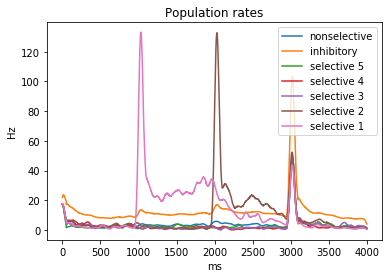

In [21]:
import matplotlib.pyplot as plt
plt.title('Population rates')
plt.xlabel('ms')
plt.ylabel('Hz')

plt.plot(r_E.t / ms, r_E.smooth_rate(width=25 * ms) / Hz, label='nonselective')
plt.plot(r_I.t / ms, r_I.smooth_rate(width=25 * ms) / Hz, label='inhibitory')

for i, r_E_sel in enumerate(r_E_sels[::-1]):
    plt.plot(r_E_sel.t / ms, r_E_sel.smooth_rate(width=25 * ms) / Hz, label='selective {}'.format(p - i))

plt.legend()

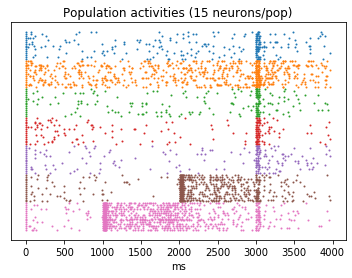

In [22]:

plt.title('Population activities ({} neurons/pop)'.format(N_activity_plot))
plt.xlabel('ms')
plt.yticks([])

plt.plot(sp_E.t / ms, sp_E.i + (p + 1) * N_activity_plot, '.', markersize=2, label='nonselective')
plt.plot(sp_I.t / ms, sp_I.i + p * N_activity_plot, '.', markersize=2, label='inhibitory')

for i, sp_E_sel in enumerate(sp_E_sels[::-1]):
    plt.plot(sp_E_sel.t / ms, sp_E_sel.i + (p - i - 1) * N_activity_plot, '.', markersize=2, label='selective {}'.format(p - i))

In [23]:
net.store('Brunel_Wang_2001', 'Blunel_Wang_2001.net')